In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
mu, sigma = 100, 15 
students = 100
num_of_questions = 10
reinforcement_questions = 5

WEIGHT = 20
PASS_THRESHOLD = 0.5
MAX_ATTEMPTS = 5

DIFFICULTY = ["easy", "medium", "hard"]
PROBABILITIES = [0.7, 0.2, 0.1]
REINFORCEMENT_PROB = [0.8, 0.2, 0.0]

IQ_QUANTILES = {
    "easy": 0.10,
    "medium": 0.50,
    "hard": 0.90
}

In [3]:
def generate_students(n):
    iq_scores = np.random.normal(mu, sigma, n)
    return [{"iq": iq, "learning": 50} for iq in iq_scores]

def generate_questions(n, probs):
    return list(np.random.choice(DIFFICULTY, size=n, p=probs))

def compute_probability(student, difficulty):
    iq = student["iq"]
    learning = student["learning"]
    quantile = IQ_QUANTILES[difficulty]
    
    A_i = (iq + learning) / (WEIGHT * quantile * 100)
    return min(1, A_i)

def answer_question(student, difficulty):
    prob = compute_probability(student, difficulty)
    result = np.random.binomial(1, prob)
    
    if result == 1:
        if difficulty == "easy":
            student["learning"] += 2
        elif difficulty == "medium":
            student["learning"] += 5
        elif difficulty == "hard":
            student["learning"] += 10
    
    return result

def run_questions(student, n, probs):
    questions = generate_questions(n, probs)
    results = [answer_question(student, q) for q in questions]
    return np.mean(results)

In [4]:
def run_case1(student_list):
    scores = []
    for student in student_list:
        score = run_questions(student, num_of_questions, PROBABILITIES)
        scores.append(score)
    return scores

In [5]:
def run_module_case2(student):
    score = run_questions(student, num_of_questions, PROBABILITIES)
    attempts = 1
    
    while score < PASS_THRESHOLD and attempts < MAX_ATTEMPTS:
        score = run_questions(student, reinforcement_questions, REINFORCEMENT_PROB)
        attempts += 1
    
    return score, attempts

In [6]:
def run_case2(student_list):
    scores, attempts = [], []
    for student in student_list:
        s, a = run_module_case2(student)
        scores.append(s)
        attempts.append(a)
    return scores, attempts

In [7]:
def teacher_intervention(student):
    student["learning"] += 15

def run_case3(student_list):
    results = []
    
    # Step 1: Run Case 2
    for student in student_list:
        score, attempts = run_module_case2(student)
        results.append([student, score, attempts])
    
    # Step 2: Select FAILED students only
    failed_students = [r for r in results if r[1] < PASS_THRESHOLD]
    
    # Step 3: Apply teacher intervention
    for student, _, _ in failed_students:
        teacher_intervention(student)
    
    # Step 4: Re-test all students
    final_scores, final_attempts = [], []
    
    for student, _, attempts in results:
        score = run_questions(student, reinforcement_questions, REINFORCEMENT_PROB)
        final_scores.append(score)
        final_attempts.append(attempts + 1)
    
    return final_scores, final_attempts

In [8]:
def run_comparison(n_students=100):
    # Generate base students
    base_students = generate_students(n_students)
    
    # Deep copy for each case
    import copy
    students_c1 = copy.deepcopy(base_students)
    students_c2 = copy.deepcopy(base_students)
    students_c3 = copy.deepcopy(base_students)
    
    # Run cases
    scores_c1 = run_case1(students_c1)
    scores_c2, attempts_c2 = run_case2(students_c2)
    scores_c3, attempts_c3 = run_case3(students_c3)
    
    # Create dataframes
    df_c1 = pd.DataFrame({
        'iq': [s['iq'] for s in students_c1],
        'final_learning': [s['learning'] for s in students_c1],
        'final_score': scores_c1,
        'passed': [1 if s >= PASS_THRESHOLD else 0 for s in scores_c1],
        'attempts': 1,
        'case': 'Case 1'
    })
    
    df_c2 = pd.DataFrame({
        'iq': [s['iq'] for s in students_c2],
        'final_learning': [s['learning'] for s in students_c2],
        'final_score': scores_c2,
        'passed': [1 if s >= PASS_THRESHOLD else 0 for s in scores_c2],
        'attempts': attempts_c2,
        'case': 'Case 2'
    })
    
    df_c3 = pd.DataFrame({
        'iq': [s['iq'] for s in students_c3],
        'final_learning': [s['learning'] for s in students_c3],
        'final_score': scores_c3,
        'passed': [1 if s >= PASS_THRESHOLD else 0 for s in scores_c3],
        'attempts': attempts_c3,
        'case': 'Case 3'
    })
    
    return df_c1, df_c2, df_c3

In [9]:
df_c1, df_c2, df_c3 = run_comparison(100)

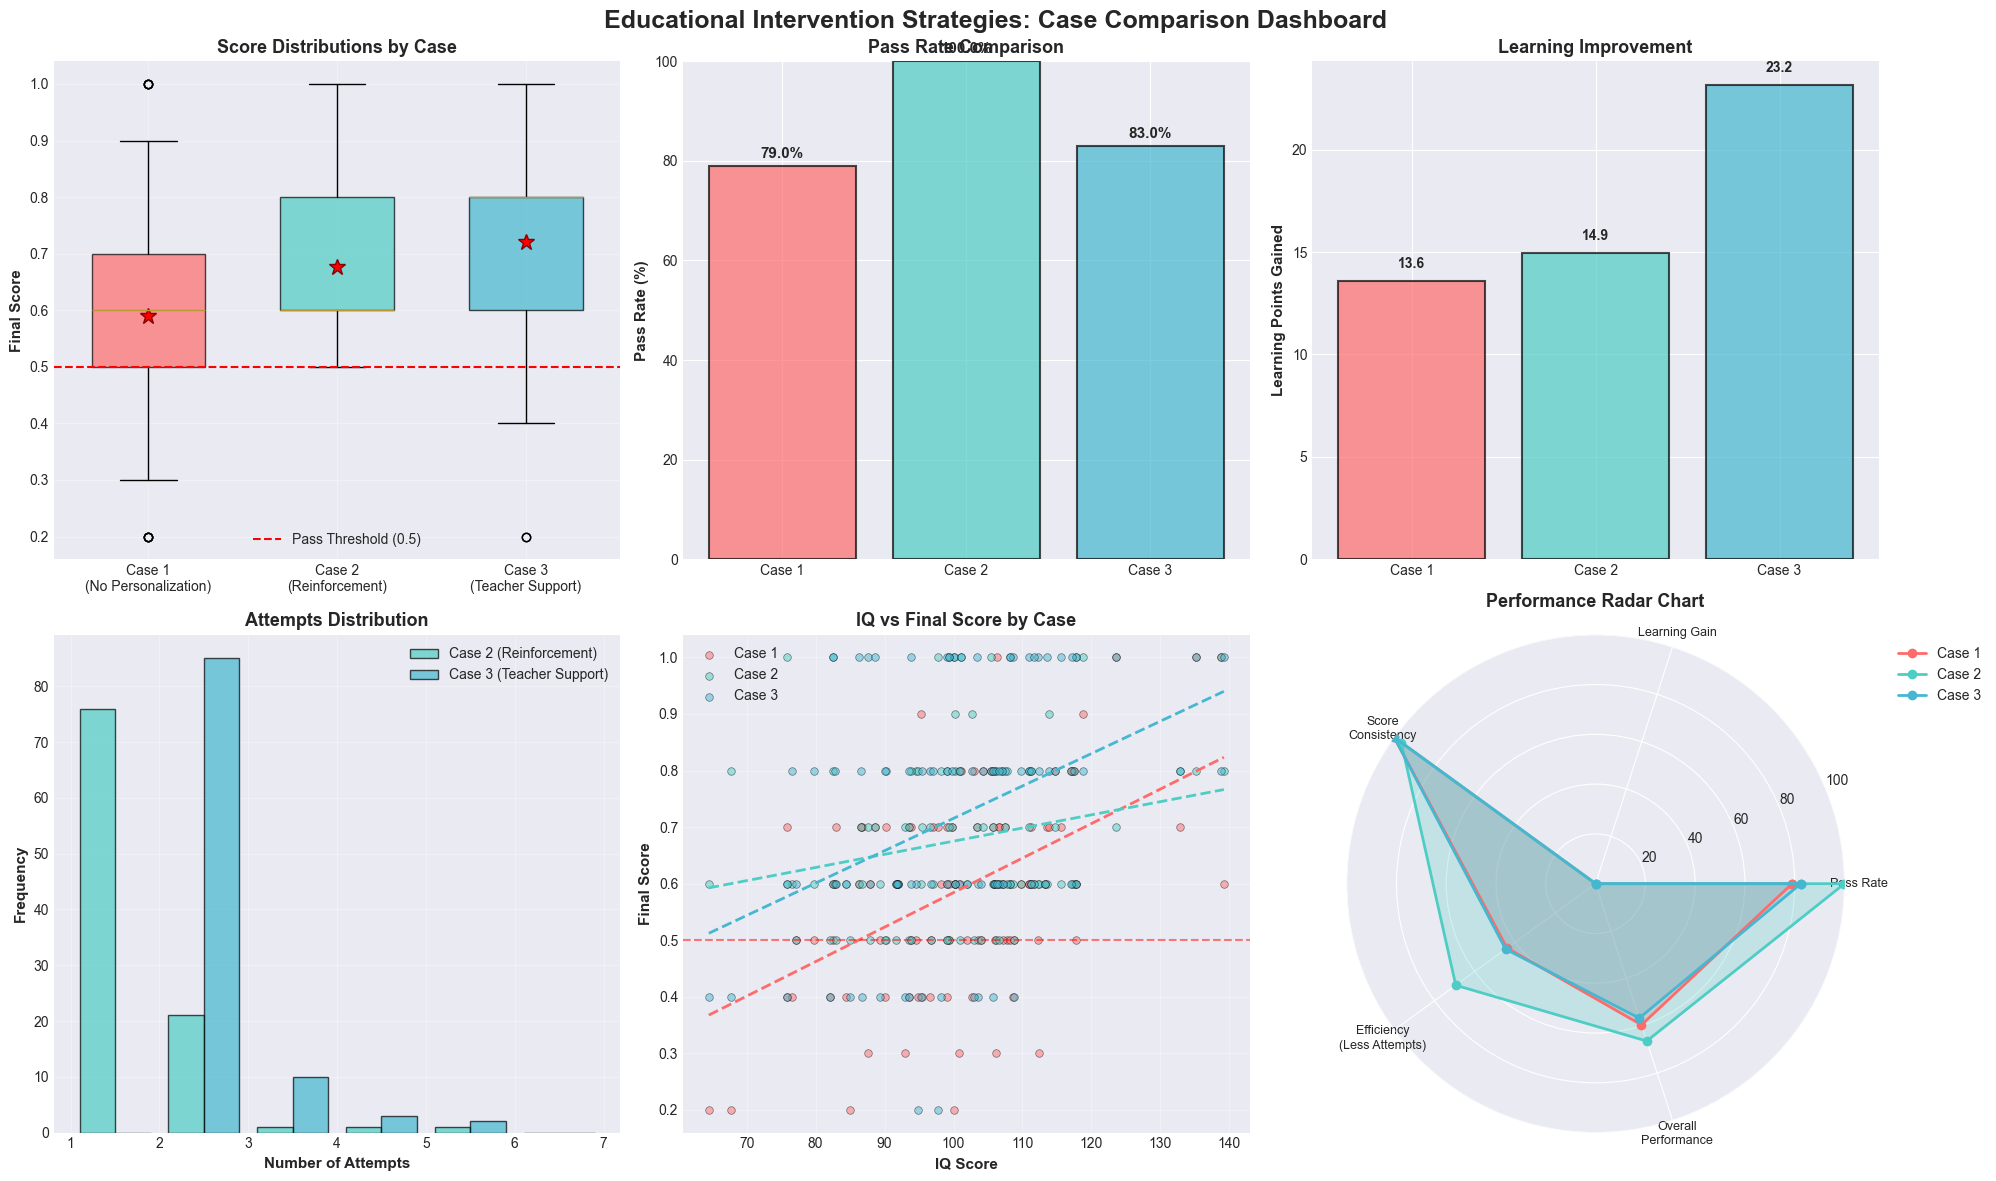

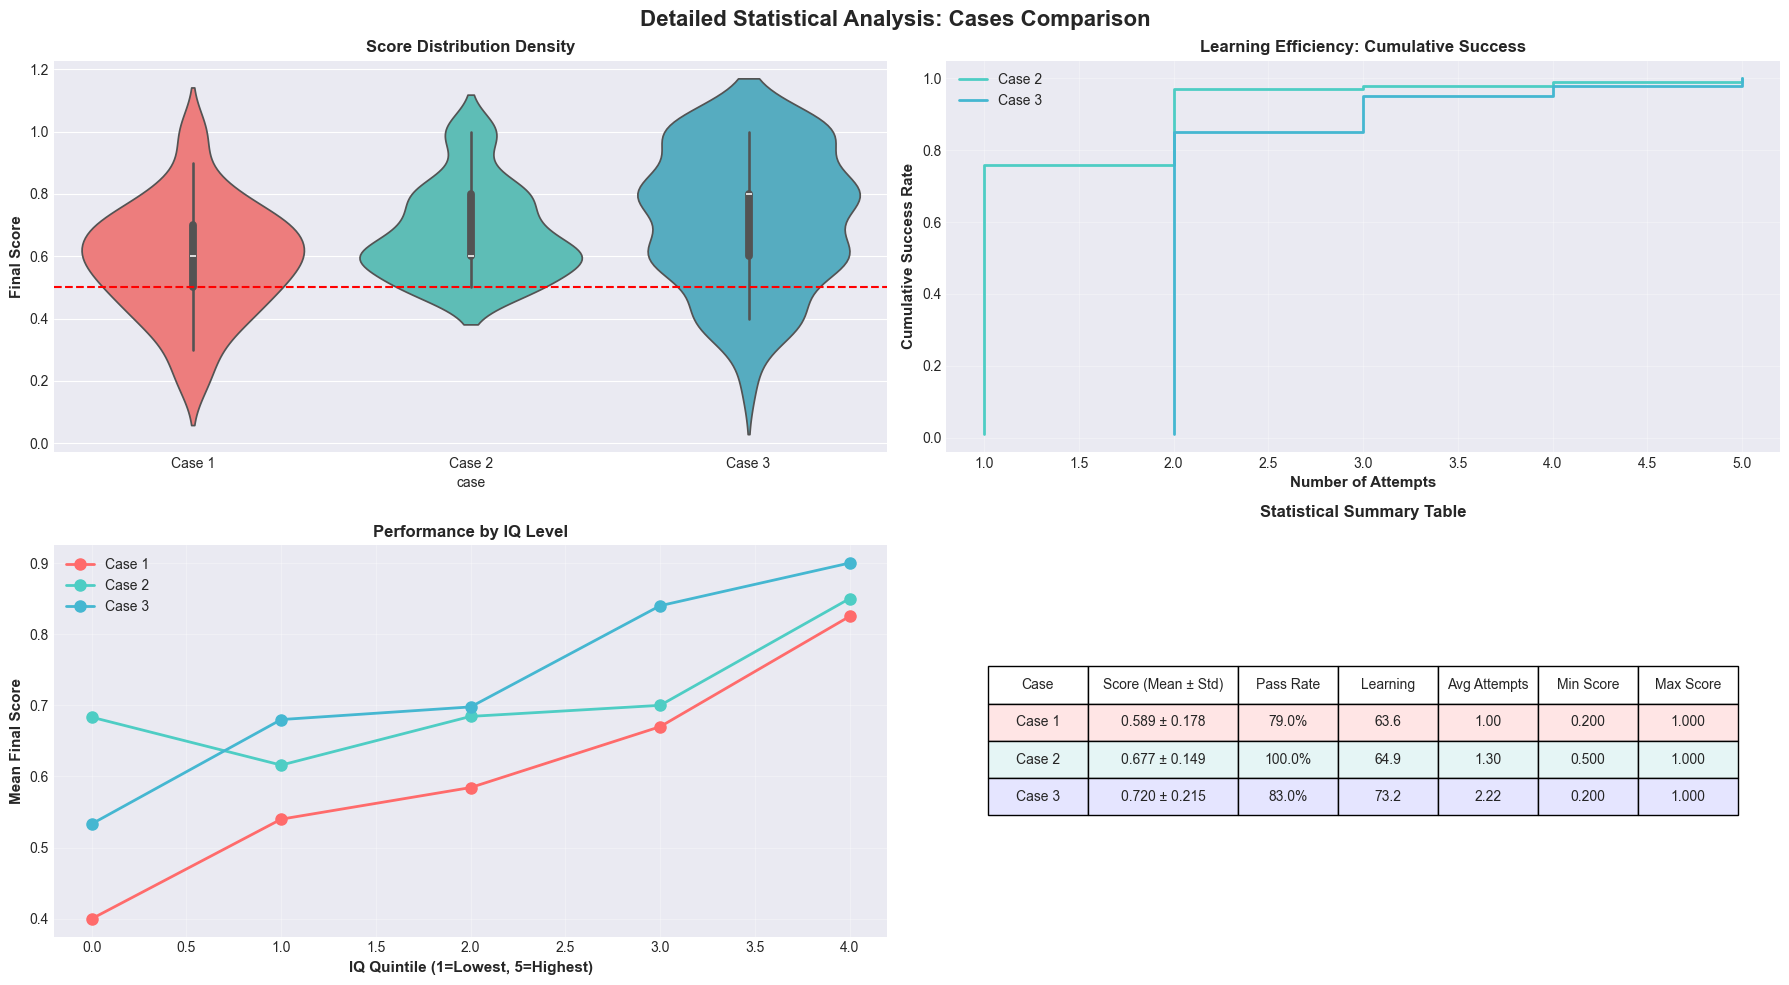

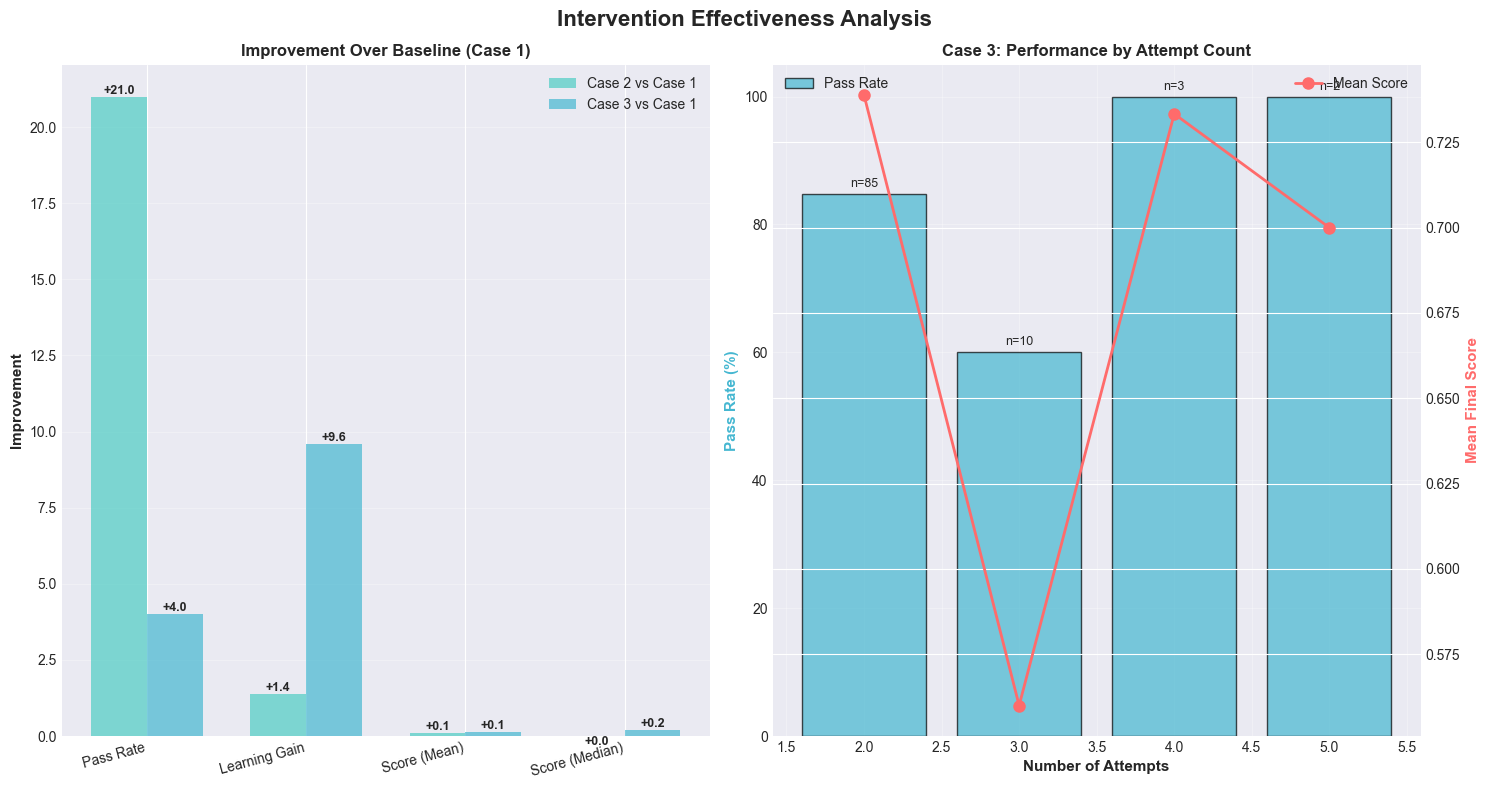

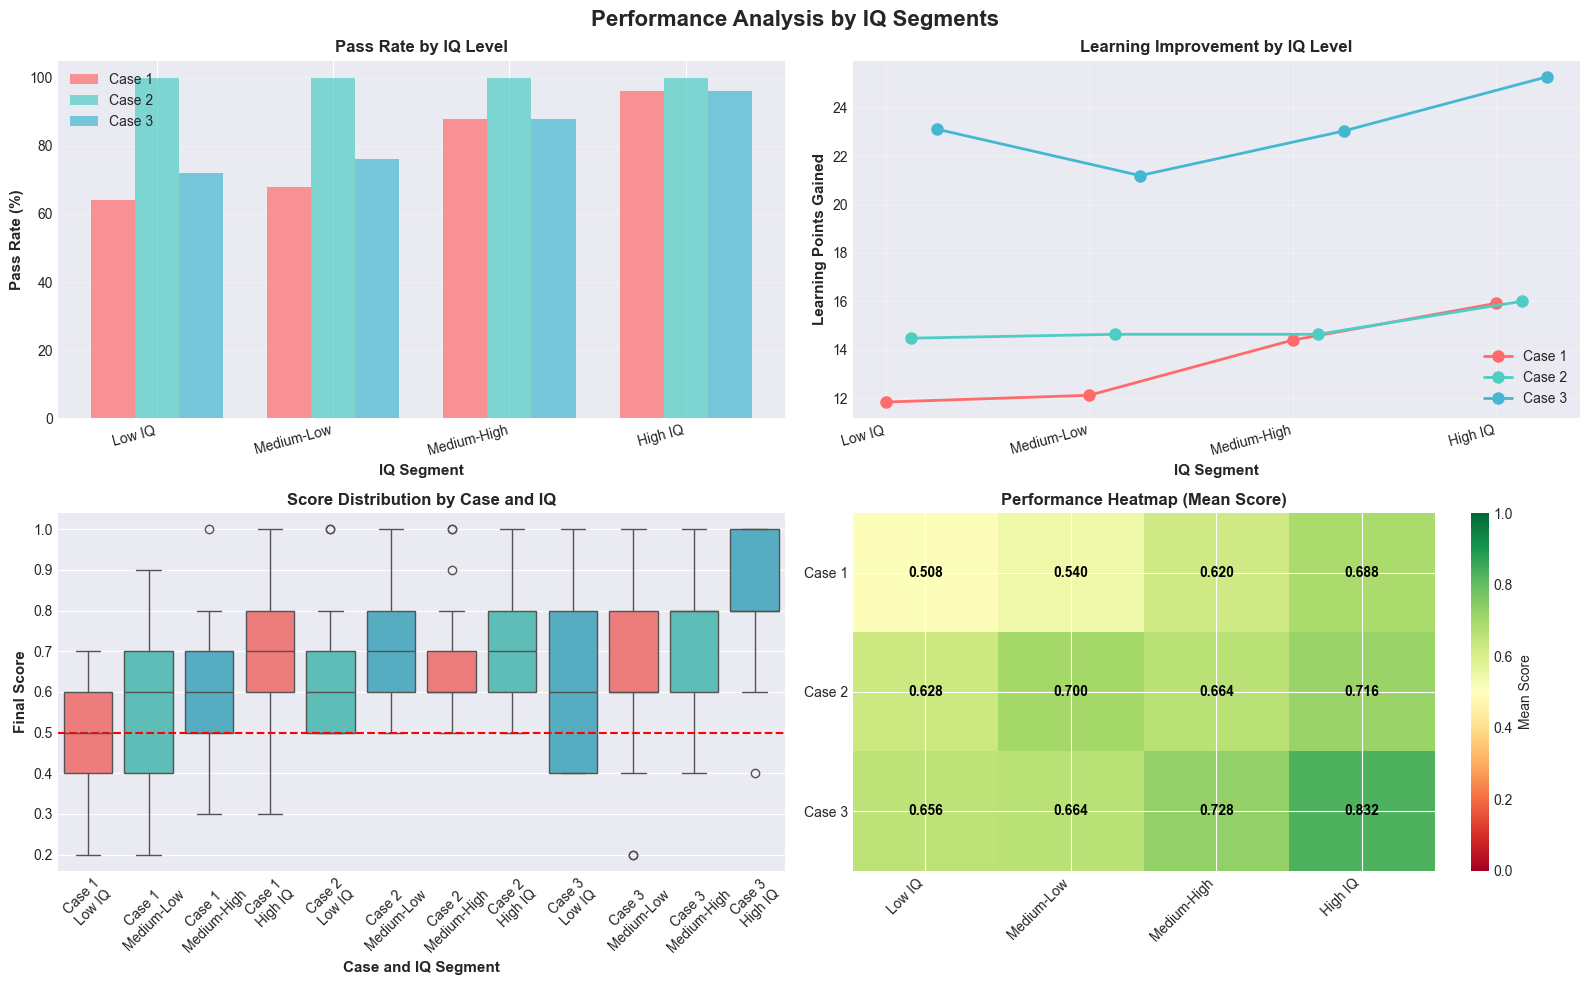


COMPREHENSIVE CASE COMPARISON SUMMARY

📊 OVERALL METRICS:
------------------------------------------------------------
Metric                    Case 1          Case 2          Case 3         
------------------------------------------------------------
Mean Score                0.589           0.677           0.720          
Median Score              0.600           0.600           0.800          
Std Deviation             0.178           0.149           0.215          
Pass Rate (%)             79.0            100.0           83.0           
Learning Points           63.6            64.9            73.2           
Avg Attempts              1.00            1.30            2.22           

📈 IMPROVEMENTS OVER BASELINE (Case 1):
------------------------------------------------------------
Metric                    Case 2 Improvement   Case 3 Improvement  
------------------------------------------------------------
Pass Rate                 +21.0%                 +4.0%
Mean Score      

In [10]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# Figure 1: Main Performance Metrics Dashboard
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Educational Intervention Strategies: Case Comparison Dashboard', 
             fontsize=18, fontweight='bold', y=0.98)

# 1.1 Score Distributions
ax1 = plt.subplot(2, 3, 1)
data_to_plot = [df_c1['final_score'], df_c2['final_score'], df_c3['final_score']]
bp = ax1.boxplot(data_to_plot, labels=['Case 1\n(No Personalization)', 
                                        'Case 2\n(Reinforcement)', 
                                        'Case 3\n(Teacher Support)'],
                 patch_artist=True, widths=0.6)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Final Score', fontsize=11, fontweight='bold')
ax1.set_title('Score Distributions by Case', fontsize=13, fontweight='bold')
ax1.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', linewidth=1.5, 
            label=f'Pass Threshold ({PASS_THRESHOLD})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add mean markers
means = [df_c1['final_score'].mean(), df_c2['final_score'].mean(), df_c3['final_score'].mean()]
for i, mean in enumerate(means, 1):
    ax1.plot(i, mean, 'r*', markersize=12, markeredgecolor='darkred', 
             markeredgewidth=1)

# 1.2 Pass Rates
ax2 = plt.subplot(2, 3, 2)
pass_rates = [
    df_c1['passed'].mean() * 100,
    df_c2['passed'].mean() * 100,
    df_c3['passed'].mean() * 100
]
bars = ax2.bar(['Case 1', 'Case 2', 'Case 3'], pass_rates, 
                color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Pass Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Pass Rate Comparison', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 100])

# Add value labels
for bar, rate in zip(bars, pass_rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 1.3 Learning Improvement
ax3 = plt.subplot(2, 3, 3)
initial_learning = 50
learning_improvements = [
    df_c1['final_learning'].mean() - initial_learning,
    df_c2['final_learning'].mean() - initial_learning,
    df_c3['final_learning'].mean() - initial_learning
]
bars = ax3.bar(['Case 1', 'Case 2', 'Case 3'], learning_improvements,
                color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Learning Points Gained', fontsize=11, fontweight='bold')
ax3.set_title('Learning Improvement', fontsize=13, fontweight='bold')

for bar, improvement in zip(bars, learning_improvements):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{improvement:.1f}', ha='center', va='bottom', fontweight='bold')

# 1.4 Attempts Distribution
ax4 = plt.subplot(2, 3, 4)
attempts_data = [df_c2['attempts'], df_c3['attempts']]
ax4.hist(attempts_data, bins=range(1, 8), alpha=0.7, 
         label=['Case 2 (Reinforcement)', 'Case 3 (Teacher Support)'],
         color=['#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=1)
ax4.set_xlabel('Number of Attempts', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Attempts Distribution', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 1.5 IQ vs Score Correlation
ax5 = plt.subplot(2, 3, 5)
for case, df, color in zip(['Case 1', 'Case 2', 'Case 3'], 
                            [df_c1, df_c2, df_c3], colors):
    ax5.scatter(df['iq'], df['final_score'], alpha=0.5, s=30, 
                label=case, color=color, edgecolors='black', linewidth=0.5)
    
    # Add trend lines
    z = np.polyfit(df['iq'], df['final_score'], 1)
    p = np.poly1d(z)
    ax5.plot(sorted(df['iq']), p(sorted(df['iq'])), 
             color=color, linewidth=2, linestyle='--')

ax5.set_xlabel('IQ Score', fontsize=11, fontweight='bold')
ax5.set_ylabel('Final Score', fontsize=11, fontweight='bold')
ax5.set_title('IQ vs Final Score by Case', fontsize=13, fontweight='bold')
ax5.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', alpha=0.5)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 1.6 Radar Chart for Overall Performance
ax6 = plt.subplot(2, 3, 6, projection='polar')
metrics = ['Pass Rate', 'Learning Gain', 'Score\nConsistency', 
           'Efficiency\n(Less Attempts)', 'Overall\nPerformance']
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

# Normalize metrics for each case
def normalize(values):
    return [(v - min(values)) / (max(values) - min(values)) * 100 if max(values) != min(values) else 50 
            for v in values]

case1_values = [
    pass_rates[0],
    learning_improvements[0],
    100 - df_c1['final_score'].std() * 20,  # Consistency (inverse of std)
    50,  # Base efficiency for case 1
    (pass_rates[0] + learning_improvements[0] + (100 - df_c1['final_score'].std() * 20)) / 3
]

case2_values = [
    pass_rates[1],
    learning_improvements[1],
    100 - df_c2['final_score'].std() * 20,
    100 * (1 - df_c2['attempts'].mean() / MAX_ATTEMPTS),
    (pass_rates[1] + learning_improvements[1] + (100 - df_c2['final_score'].std() * 20) + 
     100 * (1 - df_c2['attempts'].mean() / MAX_ATTEMPTS)) / 4
]

case3_values = [
    pass_rates[2],
    learning_improvements[2],
    100 - df_c3['final_score'].std() * 20,
    100 * (1 - df_c3['attempts'].mean() / MAX_ATTEMPTS),
    (pass_rates[2] + learning_improvements[2] + (100 - df_c3['final_score'].std() * 20) + 
     100 * (1 - df_c3['attempts'].mean() / MAX_ATTEMPTS)) / 4
]

case1_values = normalize([case1_values[i] for i in range(len(metrics))])
case2_values = normalize([case2_values[i] for i in range(len(metrics))])
case3_values = normalize([case3_values[i] for i in range(len(metrics))])

case1_values += case1_values[:1]
case2_values += case2_values[:1]
case3_values += case3_values[:1]

ax6.plot(angles, case1_values, 'o-', linewidth=2, label='Case 1', color=colors[0])
ax6.fill(angles, case1_values, alpha=0.25, color=colors[0])
ax6.plot(angles, case2_values, 'o-', linewidth=2, label='Case 2', color=colors[1])
ax6.fill(angles, case2_values, alpha=0.25, color=colors[1])
ax6.plot(angles, case3_values, 'o-', linewidth=2, label='Case 3', color=colors[2])
ax6.fill(angles, case3_values, alpha=0.25, color=colors[2])

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(metrics, fontsize=9)
ax6.set_ylim(0, 100)
ax6.set_title('Performance Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

# %%
# Figure 2: Detailed Statistical Analysis
fig2 = plt.figure(figsize=(18, 10))
fig2.suptitle('Detailed Statistical Analysis: Cases Comparison', 
              fontsize=16, fontweight='bold')

# 2.1 Violin Plots
ax1 = plt.subplot(2, 2, 1)
all_scores = pd.concat([df_c1['final_score'], df_c2['final_score'], df_c3['final_score']])
all_cases = pd.concat([df_c1['case'], df_c2['case'], df_c3['case']])
data_for_violin = pd.DataFrame({'score': all_scores, 'case': all_cases})
sns.violinplot(data=data_for_violin, x='case', y='score', palette=colors, ax=ax1)
ax1.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Final Score', fontsize=11, fontweight='bold')
ax1.set_title('Score Distribution Density', fontsize=12, fontweight='bold')

# 2.2 Cumulative Success Curve
ax2 = plt.subplot(2, 2, 2)
for df, label, color in zip([df_c2, df_c3], ['Case 2', 'Case 3'], colors[1:3]):
    attempts_sorted = np.sort(df['attempts'])
    cumulative_success = np.arange(1, len(attempts_sorted) + 1) / len(attempts_sorted)
    ax2.step(attempts_sorted, cumulative_success, where='post', 
             label=label, linewidth=2, color=color)
ax2.set_xlabel('Number of Attempts', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Success Rate', fontsize=11, fontweight='bold')
ax2.set_title('Learning Efficiency: Cumulative Success', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 2.3 Learning Trajectory (IQ-based analysis)
ax3 = plt.subplot(2, 2, 3)
iq_bins = pd.cut(df_c1['iq'], bins=5)
for case, df, color in zip(['Case 1', 'Case 2', 'Case 3'], 
                            [df_c1, df_c2, df_c3], colors):
    mean_by_iq = df.groupby(iq_bins)['final_score'].mean()
    ax3.plot(range(len(mean_by_iq)), mean_by_iq.values, 'o-', 
             label=case, color=color, linewidth=2, markersize=8)
ax3.set_xlabel('IQ Quintile (1=Lowest, 5=Highest)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Mean Final Score', fontsize=11, fontweight='bold')
ax3.set_title('Performance by IQ Level', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 2.4 Statistical Summary Table
ax4 = plt.subplot(2, 2, 4)
ax4.axis('tight')
ax4.axis('off')

# Prepare statistical summary
summary_data = []
for case, df in zip(['Case 1', 'Case 2', 'Case 3'], [df_c1, df_c2, df_c3]):
    summary_data.append([
        case,
        f"{df['final_score'].mean():.3f} ± {df['final_score'].std():.3f}",
        f"{df['passed'].mean()*100:.1f}%",
        f"{df['final_learning'].mean():.1f}",
        f"{df['attempts'].mean():.2f}" if 'attempts' in df else "1.00",
        f"{df['final_score'].min():.3f}",
        f"{df['final_score'].max():.3f}"
    ])

columns = ['Case', 'Score (Mean ± Std)', 'Pass Rate', 'Learning', 'Avg Attempts', 'Min Score', 'Max Score']
table = ax4.table(cellText=summary_data, colLabels=columns, 
                  cellLoc='center', loc='center',
                  colWidths=[0.12, 0.18, 0.12, 0.12, 0.12, 0.12, 0.12])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Color coding
for i, case in enumerate(['Case 1', 'Case 2', 'Case 3']):
    for j in range(len(columns)):
        cell = table[(i+1, j)]
        if i == 0:
            cell.set_facecolor('#FFE5E5')
        elif i == 1:
            cell.set_facecolor('#E5F5F5')
        else:
            cell.set_facecolor('#E5E5FF')

ax4.set_title('Statistical Summary Table', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# %%
# Figure 3: Improvement Analysis
fig3 = plt.figure(figsize=(15, 8))
fig3.suptitle('Intervention Effectiveness Analysis', fontsize=16, fontweight='bold')

# 3.1 Improvement from Case 1 baseline
ax1 = plt.subplot(1, 2, 1)
improvements = {
    'Metric': ['Pass Rate', 'Learning Gain', 'Score (Mean)', 'Score (Median)'],
    'Case 2 vs Case 1': [
        (df_c2['passed'].mean() - df_c1['passed'].mean()) * 100,
        df_c2['final_learning'].mean() - df_c1['final_learning'].mean(),
        df_c2['final_score'].mean() - df_c1['final_score'].mean(),
        df_c2['final_score'].median() - df_c1['final_score'].median()
    ],
    'Case 3 vs Case 1': [
        (df_c3['passed'].mean() - df_c1['passed'].mean()) * 100,
        df_c3['final_learning'].mean() - df_c1['final_learning'].mean(),
        df_c3['final_score'].mean() - df_c1['final_score'].mean(),
        df_c3['final_score'].median() - df_c1['final_score'].median()
    ]
}

x = np.arange(len(improvements['Metric']))
width = 0.35
bars1 = ax1.bar(x - width/2, improvements['Case 2 vs Case 1'], width, 
                label='Case 2 vs Case 1', color='#4ECDC4', alpha=0.7)
bars2 = ax1.bar(x + width/2, improvements['Case 3 vs Case 1'], width,
                label='Case 3 vs Case 1', color='#45B7D1', alpha=0.7)

ax1.set_ylabel('Improvement', fontsize=11, fontweight='bold')
ax1.set_title('Improvement Over Baseline (Case 1)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(improvements['Metric'], rotation=15, ha='right')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:+.1f}', ha='center', va='bottom' if height > 0 else 'top',
                fontweight='bold', fontsize=9)

# 3.2 Success Rate by Attempts (Case 3)
ax2 = plt.subplot(1, 2, 2)
attempt_groups = df_c3.groupby('attempts').agg({
    'passed': 'mean',
    'final_score': 'mean',
    'iq': 'count'
}).reset_index()

ax2_twin = ax2.twinx()
bars = ax2.bar(attempt_groups['attempts'], attempt_groups['passed'] * 100,
               alpha=0.7, color='#45B7D1', edgecolor='black',
               label='Pass Rate')
line = ax2_twin.plot(attempt_groups['attempts'], attempt_groups['final_score'],
                     'o-', color='#FF6B6B', linewidth=2, markersize=8,
                     label='Mean Score')

ax2.set_xlabel('Number of Attempts', fontsize=11, fontweight='bold')
ax2.set_ylabel('Pass Rate (%)', fontsize=11, fontweight='bold', color='#45B7D1')
ax2_twin.set_ylabel('Mean Final Score', fontsize=11, fontweight='bold', color='#FF6B6B')
ax2.set_title('Case 3: Performance by Attempt Count', fontsize=12, fontweight='bold')

# Add sample size annotations
for idx, row in attempt_groups.iterrows():
    ax2.annotate(f'n={int(row["iq"])}', 
                (row['attempts'], row['passed'] * 100),
                textcoords="offset points", xytext=(0, 5), 
                ha='center', fontsize=9)

ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Figure 4: Distribution Analysis by IQ Segments
fig4 = plt.figure(figsize=(16, 10))
fig4.suptitle('Performance Analysis by IQ Segments', fontsize=16, fontweight='bold')

# Create IQ segments
iq_segments = pd.qcut(df_c1['iq'], q=4, labels=['Low IQ', 'Medium-Low', 'Medium-High', 'High IQ'])

# 4.1 Pass Rate by IQ Segment
ax1 = plt.subplot(2, 2, 1)
x = np.arange(len(iq_segments.cat.categories))
width = 0.25

for i, (df, label, color) in enumerate(zip([df_c1, df_c2, df_c3], 
                                            ['Case 1', 'Case 2', 'Case 3'], 
                                            colors)):
    pass_by_iq = df.groupby(iq_segments)['passed'].mean() * 100
    ax1.bar(x + i*width, pass_by_iq.values, width, label=label, color=color, alpha=0.7)

ax1.set_xlabel('IQ Segment', fontsize=11, fontweight='bold')
ax1.set_ylabel('Pass Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Pass Rate by IQ Level', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(iq_segments.cat.categories, rotation=15, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 4.2 Learning Gain by IQ Segment
ax2 = plt.subplot(2, 2, 2)
for i, (df, label, color) in enumerate(zip([df_c1, df_c2, df_c3], 
                                            ['Case 1', 'Case 2', 'Case 3'], 
                                            colors)):
    learning_by_iq = df.groupby(iq_segments)['final_learning'].mean() - initial_learning
    ax2.plot(x + i*width/2, learning_by_iq.values, 'o-', label=label, 
             color=color, linewidth=2, markersize=8)

ax2.set_xlabel('IQ Segment', fontsize=11, fontweight='bold')
ax2.set_ylabel('Learning Points Gained', fontsize=11, fontweight='bold')
ax2.set_title('Learning Improvement by IQ Level', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(iq_segments.cat.categories, rotation=15, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 4.3 Score Distribution by IQ Segment (Boxplot)
ax3 = plt.subplot(2, 2, 3)
data_for_box = []
labels_for_box = []
for i, (df, label) in enumerate(zip([df_c1, df_c2, df_c3], ['Case 1', 'Case 2', 'Case 3'])):
    for iq_level in iq_segments.cat.categories:
        mask = iq_segments == iq_level
        scores = df[mask]['final_score'].values
        data_for_box.extend(scores)
        labels_for_box.extend([f'{label}\n{iq_level}'] * len(scores))

box_data = pd.DataFrame({'score': data_for_box, 'group': labels_for_box})
sns.boxplot(data=box_data, x='group', y='score', palette=colors*4, ax=ax3)
ax3.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Case and IQ Segment', fontsize=11, fontweight='bold')
ax3.set_ylabel('Final Score', fontsize=11, fontweight='bold')
ax3.set_title('Score Distribution by Case and IQ', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 4.4 Heatmap of Performance
ax4 = plt.subplot(2, 2, 4)
heatmap_data = pd.DataFrame({
    'Case 1 - Low IQ': df_c1[iq_segments == 'Low IQ']['final_score'].mean(),
    'Case 1 - Medium-Low': df_c1[iq_segments == 'Medium-Low']['final_score'].mean(),
    'Case 1 - Medium-High': df_c1[iq_segments == 'Medium-High']['final_score'].mean(),
    'Case 1 - High IQ': df_c1[iq_segments == 'High IQ']['final_score'].mean(),
    'Case 2 - Low IQ': df_c2[iq_segments == 'Low IQ']['final_score'].mean(),
    'Case 2 - Medium-Low': df_c2[iq_segments == 'Medium-Low']['final_score'].mean(),
    'Case 2 - Medium-High': df_c2[iq_segments == 'Medium-High']['final_score'].mean(),
    'Case 2 - High IQ': df_c2[iq_segments == 'High IQ']['final_score'].mean(),
    'Case 3 - Low IQ': df_c3[iq_segments == 'Low IQ']['final_score'].mean(),
    'Case 3 - Medium-Low': df_c3[iq_segments == 'Medium-Low']['final_score'].mean(),
    'Case 3 - Medium-High': df_c3[iq_segments == 'Medium-High']['final_score'].mean(),
    'Case 3 - High IQ': df_c3[iq_segments == 'High IQ']['final_score'].mean(),
}, index=['Mean Score'])

heatmap_data_matrix = heatmap_data.values.reshape(3, 4)
im = ax4.imshow(heatmap_data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax4.set_xticks(range(4))
ax4.set_yticks(range(3))
ax4.set_xticklabels(['Low IQ', 'Medium-Low', 'Medium-High', 'High IQ'], rotation=45, ha='right')
ax4.set_yticklabels(['Case 1', 'Case 2', 'Case 3'])
ax4.set_title('Performance Heatmap (Mean Score)', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(3):
    for j in range(4):
        text = ax4.text(j, i, f'{heatmap_data_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax4, label='Mean Score')
plt.tight_layout()
plt.show()

# %%
# Print Statistical Summary
print("\n" + "="*80)
print("COMPREHENSIVE CASE COMPARISON SUMMARY")
print("="*80)

print("\n📊 OVERALL METRICS:")
print("-" * 60)
print(f"{'Metric':<25} {'Case 1':<15} {'Case 2':<15} {'Case 3':<15}")
print("-" * 60)
print(f"{'Mean Score':<25} {df_c1['final_score'].mean():<15.3f} {df_c2['final_score'].mean():<15.3f} {df_c3['final_score'].mean():<15.3f}")
print(f"{'Median Score':<25} {df_c1['final_score'].median():<15.3f} {df_c2['final_score'].median():<15.3f} {df_c3['final_score'].median():<15.3f}")
print(f"{'Std Deviation':<25} {df_c1['final_score'].std():<15.3f} {df_c2['final_score'].std():<15.3f} {df_c3['final_score'].std():<15.3f}")
print(f"{'Pass Rate (%)':<25} {df_c1['passed'].mean()*100:<15.1f} {df_c2['passed'].mean()*100:<15.1f} {df_c3['passed'].mean()*100:<15.1f}")
print(f"{'Learning Points':<25} {df_c1['final_learning'].mean():<15.1f} {df_c2['final_learning'].mean():<15.1f} {df_c3['final_learning'].mean():<15.1f}")
print(f"{'Avg Attempts':<25} {'1.00':<15} {df_c2['attempts'].mean():<15.2f} {df_c3['attempts'].mean():<15.2f}")

print("\n📈 IMPROVEMENTS OVER BASELINE (Case 1):")
print("-" * 60)
print(f"{'Metric':<25} {'Case 2 Improvement':<20} {'Case 3 Improvement':<20}")
print("-" * 60)
print(f"{'Pass Rate':<25} {(df_c2['passed'].mean() - df_c1['passed'].mean())*100:+.1f}%{'':<16} {(df_c3['passed'].mean() - df_c1['passed'].mean())*100:+.1f}%")
print(f"{'Mean Score':<25} {df_c2['final_score'].mean() - df_c1['final_score'].mean():+.3f}{'':<17} {df_c3['final_score'].mean() - df_c1['final_score'].mean():+.3f}")
print(f"{'Learning Gain':<25} {df_c2['final_learning'].mean() - df_c1['final_learning'].mean():+.1f}{'':<17} {df_c3['final_learning'].mean() - df_c1['final_learning'].mean():+.1f}")

print("\n🎯 KEY FINDINGS:")
print("-" * 60)
print(f"1. Best Overall Performance: {'Case 3' if df_c3['final_score'].mean() > max(df_c1['final_score'].mean(), df_c2['final_score'].mean()) else 'Case 2'}")
print(f"2. Most Efficient Learning: {'Case 3' if df_c3['attempts'].mean() < df_c2['attempts'].mean() else 'Case 2'} (avg {min(df_c2['attempts'].mean(), df_c3['attempts'].mean()):.2f} attempts)")
print(f"3. Most Consistent Performance: {'Case 3' if df_c3['final_score'].std() < min(df_c1['final_score'].std(), df_c2['final_score'].std()) else 'Case 1'}")
print(f"4. Highest Pass Rate: Case 3 ({df_c3['passed'].mean()*100:.1f}%)")
print(f"5. Best for Low IQ Students: {'Case 3' if df_c3[iq_segments == 'Low IQ']['passed'].mean() > max(df_c1[iq_segments == 'Low IQ']['passed'].mean(), df_c2[iq_segments == 'Low IQ']['passed'].mean()) else 'Case 2'}")

print("\n💡 RECOMMENDATIONS:")
print("-" * 60)
if df_c3['final_score'].mean() > df_c2['final_score'].mean() * 1.1:
    print("✓ Case 3 (Teacher Support) provides significantly better results")
    print("  - Best for improving pass rates and learning outcomes")
    print("  - Particularly effective for struggling students")
elif df_c2['final_score'].mean() > df_c3['final_score'].mean():
    print("✓ Case 2 (Reinforcement) is more effective in this scenario")
    print("  - Better for self-paced learning")
    print("  - Requires fewer resources than teacher intervention")
else:
    print("✓ Both Case 2 and Case 3 show similar effectiveness")
    print("  - Choose based on available resources")
    print("  - Case 2 for independent learning environments")
    print("  - Case 3 for structured educational settings")

print("\n" + "="*80)

In [11]:
df_c1.to_csv('case1_results.csv', index=False)
df_c2.to_csv('case2_results.csv', index=False)
df_c3.to_csv('case3_results.csv', index=False)
print("\n✅ Results saved to CSV files: case1_results.csv, case2_results.csv, case3_results.csv")


✅ Results saved to CSV files: case1_results.csv, case2_results.csv, case3_results.csv
